# Frozen v14 vs v15 seed-1 100k qualification diagnostics

## tl;dr

- Both sealed CSVs validate at their preregistered hashes, share the same ordered 922-column schema, contain only complete rows, and have strict unique integer `real_step`. The canonical populations are v14: 63 rows / 7,703 held-out decisions (70,032–99,376), and v15: 58 rows / 8,154 (70,240–99,920); overshoots 100,112 and 100,736 are excluded.
- Among the CSV-observable frozen numeric gates, **held-out EMA selected-action TD RMSE is the only failure in each run**: v14 is 0.5247954789453232 and v15 is 0.5637126651551874 versus the unchanged 0.5 ceiling. V15's excess SSE budget is 552.6126, versus 195.7355 for v14.
- The change is not a uniform regression. EMA RMSE moves W1 0.3070→0.6350 and W2 0.4806→0.5262, but W3 improves 0.8753→0.5363. All three v15 windows nevertheless exceed 0.5.
- Frozen behavior evidence still passes: teacher/student gaps, retention, signed margin, support fractions, trailing-five stability, wrong-CONTINUE saturation, online-vs-EMA sign agreement, and actor/Q/gate CSV safety counters. Online-vs-EMA agreement declines from 46,420/61,714 = 0.75218 to 45,743/66,055 = 0.69250, remaining above 0.60; exact projected-gate sign agreement remains 1.0.
- Reconstructed train online RMSE improves from 0.58679 to 0.48947 while held-out online RMSE worsens from 0.52481 to 0.56469. V15 logged half-MSE reconciles to reconstructed train half-MSE (0.11979008); v14's logged Huber is 0.12421774 versus reconstructed half-MSE 0.17216289. These populations are policy-coupled and are not a controlled generalization experiment.
- Held-out error becomes less top-row concentrated (top-10 SSE share 79.99%→69.39%) but more heterogeneous across rows: between-row mean-bias variance rises from 0.09656 to 0.12852 while pooled global bias stays near zero.
- The immediate schema-9 lineage recommendation is an attribution choice, not an efficacy inference: preserve v15 half-MSE and change only the common-mode one-delta semantics. The v14-Huber-plus-common sibling is second priority despite its lower observed RMSE/gradient risk because it changes two semantics relative to schema 8. Neither option is predicted to pass from these observations.

> **Evidence boundary:** every measurement below is descriptive of two single-seed, separately generated trajectories. The lineage ordering is supplied as an attribution tradeoff; the notebook does not infer a causal fix, simulate a retrain, predict a pass, authorize an experiment, or treat temporal association as causation.


## Context & Methods

The goal is to reconcile the authoritative CSV-observable qualification metrics first, then describe where v14 and v15 differ in calibration, loss regime, error concentration, and update density. Both runs are fresh seed-1 100k qualifications, but they are separate on-policy trajectories with different row cadence and decision support.

### Key assumptions

- Canonical rows satisfy the exact predicate `70000 < real_step <= 100000`; rows are never interpolated, paired, reordered, or truncated.
- Sufficient statistics are pooled: `sum(n_i * x_i) / sum(n_i)`. RMSE is `sqrt(sum(n_i * rmse_i**2) / sum(n_i))`. Event successes are reconstructed as the nearest integer to `n_i * rate_i` only when every residual is at most `1e-4`.
- Teacher/student gaps and signed margin use the all-valid EMA `actor/voc_gate_acceptance_*` fields and their matching sign/non-tie counts.
- Train online/EMA moments are reconstructed row by row from all-valid moments less held-out moments. This is exact sufficient-statistic subtraction, subject only to CSV float precision.
- V14 `actor/voc_q_loss` is mean beta-1 Smooth-L1/Huber; v15 is mean half-squared TD error. The raw logged loss values are therefore not definition-identical.
- Row-bias decomposition is exact for the logged row moments: total EMA MSE = within-row error variance + between-row mean-bias variance + pooled bias squared. It does not expose individual errors or state/action strata.
- ModelNet safety and non-CSV integrity artifacts are outside the two supplied CSV inputs. Their absence is a validation boundary, not evidence of failure.


In [1]:
from pathlib import Path
import csv
import hashlib
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PRODUCTION_PYTHON = Path('/home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python')
SOURCES = {
    'v14': {
        'path': Path('/tmp/di-voc-v14-sealed-eps25-final-eKgdrk/runs/enduro-voc-v14-sealed-eps25-seed1-qual-fresh-100k/logs.csv'),
        'sha256': '6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8',
    },
    'v15': {
        'path': Path('/tmp/di-voc-v15-halfsq-eps25-final-CKcYfI/runs/enduro-voc-v15-halfsq-eps25-seed1-qual-fresh-100k/logs.csv'),
        'sha256': '359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d67800f0308f448e341',
    },
}
EXPECTED_PROFILES = {
    'v14': {'shape': (204, 922), 'rows': 63, 'first': 70032, 'last': 99376, 'overshoot': [100112]},
    'v15': {'shape': (149, 922), 'rows': 58, 'first': 70240, 'last': 99920, 'overshoot': [100736]},
}
WINDOWS = (('W1', 70000, 80000), ('W2', 80000, 90000), ('W3', 90000, 100000))
LOWER_STEP, UPPER_STEP, RMSE_CEILING = 70000, 100000, 0.5

assert sys.version_info[:2] == (3, 10), sys.version
assert Path(sys.executable).resolve() == PRODUCTION_PYTHON.resolve(), sys.executable
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
print(f'Python {platform.python_version()} | {sys.executable}')
print(f'pandas={pd.__version__}, numpy={np.__version__}, matplotlib={plt.matplotlib.__version__}')


Python 3.10.21 | /home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python
pandas=2.3.3, numpy=1.26.4, matplotlib=3.10.9


## Data validation

### 1. Validate hashes, raw headers, completeness, and strict populations

Raw CSV headers are checked before pandas parsing so duplicate names cannot be hidden by name mangling. Every source identity and population assertion fails closed.


In [2]:
frames, canonical, source_headers, data_quality_rows = {}, {}, {}, []
for version, source in SOURCES.items():
    path = source['path']
    assert path.is_file(), path
    actual_sha256 = hashlib.sha256(path.read_bytes()).hexdigest()
    assert actual_sha256 == source['sha256'], (version, actual_sha256)
    with path.open('r', encoding='utf-8', newline='') as handle:
        raw_header = next(csv.reader(handle))
    assert len(raw_header) == 922 and len(set(raw_header)) == 922
    frame = pd.read_csv(path)
    expected = EXPECTED_PROFILES[version]
    assert frame.shape == expected['shape'], (version, frame.shape)
    assert list(frame.columns) == raw_header
    complete_rows = int(frame.notna().all(axis=1).sum())
    assert complete_rows == len(frame)
    numeric = frame.select_dtypes(include=[np.number])
    assert numeric.shape[1] == 917 and np.isfinite(numeric.to_numpy(dtype=np.float64)).all()
    steps = pd.to_numeric(frame['real_step'], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(steps).all() and np.equal(steps, np.rint(steps)).all()
    assert np.all(np.diff(steps) > 0) and frame.real_step.is_unique
    population = frame.loc[(frame.real_step > LOWER_STEP) & (frame.real_step <= UPPER_STEP)].copy().reset_index(drop=True)
    overshoot = frame.loc[frame.real_step > UPPER_STEP, 'real_step'].astype(int).tolist()
    assert len(population) == expected['rows']
    assert (int(population.real_step.iloc[0]), int(population.real_step.iloc[-1])) == (expected['first'], expected['last'])
    assert overshoot == expected['overshoot']
    frames[version], canonical[version], source_headers[version] = frame, population, raw_header
    data_quality_rows.append({
        'version': version, 'sha256': actual_sha256, 'rows_all': len(frame), 'columns': len(raw_header),
        'complete_rows': complete_rows, 'numeric_columns_finite': numeric.shape[1], 'strict_unique_steps': True, 'canonical_rows': len(population),
        'first_step': int(population.real_step.iloc[0]), 'last_step': int(population.real_step.iloc[-1]),
        'excluded_overshoot': overshoot[0],
    })
assert source_headers['v14'] == source_headers['v15']
data_quality = pd.DataFrame(data_quality_rows)
display(data_quality)
print('Ordered schemas identical:', source_headers['v14'] == source_headers['v15'])


,version,sha256,rows_all,columns,complete_rows,numeric_columns_finite,strict_unique_steps,canonical_rows,first_step,last_step,excluded_overshoot
0,v14,6d72052279a59983d102bed3db767b3792b115d221f155...,204,922,204,917,True,63,70032,99376,100112
1,v15,359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d...,149,922,149,917,True,58,70240,99920,100736


Ordered schemas identical: True


## Results

### 2. Reproduce the CSV-observable frozen qualification gates first


In [3]:
HOLDOUT_COUNT = 'actor/voc_holdout_count'
GATE_PREFIX = 'actor/voc_gate_acceptance'

def require_counts(series, label):
    values = pd.to_numeric(series, errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and (values >= 0).all(), label
    assert np.allclose(values, np.rint(values), rtol=0.0, atol=1e-9), label
    return values.astype(np.int64)

def pooled_mean(frame, value_column, count_column):
    counts = require_counts(frame[count_column], count_column).astype(np.float64)
    values = pd.to_numeric(frame[value_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and counts.sum() > 0
    return float(np.dot(counts, values) / counts.sum())

def pooled_rmse(frame, rmse_column, count_column=HOLDOUT_COUNT):
    counts = require_counts(frame[count_column], count_column).astype(np.float64)
    values = pd.to_numeric(frame[rmse_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and (values >= 0).all() and counts.sum() > 0
    return float(np.sqrt(np.dot(counts, np.square(values)) / counts.sum()))

def reconstructed_event_rate(frame, count_column, rate_column, tolerance=1e-4):
    counts = require_counts(frame[count_column], count_column)
    rates = pd.to_numeric(frame[rate_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(rates).all() and ((rates >= 0) & (rates <= 1)).all()
    raw = counts.astype(np.float64) * rates
    successes = np.rint(raw).astype(np.int64)
    residual = np.abs(raw - successes)
    assert (residual <= tolerance).all(), (count_column, rate_column, float(residual.max()))
    return int(successes.sum()), int(counts.sum()), float(residual.max())

def gap_metrics(frame):
    positive_count = f'{GATE_PREFIX}_delta_q_positive_count'
    negative_count = f'{GATE_PREFIX}_delta_q_negative_count'
    nontie_count = f'{GATE_PREFIX}_delta_q_nontie_count'
    teacher_gap = (
        pooled_mean(frame, f'{GATE_PREFIX}_teacher_continue_probability_delta_positive', positive_count)
        - pooled_mean(frame, f'{GATE_PREFIX}_teacher_continue_probability_delta_negative', negative_count)
    )
    student_gap = (
        pooled_mean(frame, f'{GATE_PREFIX}_continue_probability_delta_positive', positive_count)
        - pooled_mean(frame, f'{GATE_PREFIX}_continue_probability_delta_negative', negative_count)
    )
    margin = pooled_mean(frame, f'{GATE_PREFIX}_signed_gate_margin', nontie_count)
    return teacher_gap, student_gap, student_gap / teacher_gap, margin

def trailing_five(frame):
    positive_count = f'{GATE_PREFIX}_delta_q_positive_count'
    negative_count = f'{GATE_PREFIX}_delta_q_negative_count'
    positive_value = f'{GATE_PREFIX}_continue_probability_delta_positive'
    negative_value = f'{GATE_PREFIX}_continue_probability_delta_negative'
    records = []
    for endpoint in range(4, len(frame)):
        window = frame.iloc[endpoint - 4:endpoint + 1]
        positive_n = int(require_counts(window[positive_count], positive_count).sum())
        negative_n = int(require_counts(window[negative_count], negative_count).sum())
        gap = np.nan
        if positive_n > 0 and negative_n > 0:
            gap = pooled_mean(window, positive_value, positive_count) - pooled_mean(window, negative_value, negative_count)
        records.append({'real_step': int(frame.real_step.iloc[endpoint]), 'positive_n': positive_n, 'negative_n': negative_n, 'student_gap': gap})
    result = pd.DataFrame(records)
    run = max_run = 0
    for is_negative in (result.student_gap < 0).tolist():
        run = run + 1 if is_negative else 0
        max_run = max(max_run, run)
    return result, max_run

SAFETY_COLUMNS = [
    'actor/amp_skip_count', 'actor/amp_consecutive_skips', 'actor/nonfinite_gradient_parameter_count',
    'voc/amp_skip_count', 'voc/amp_consecutive_skips', 'voc/nonfinite_gradient_parameter_count',
    'voc_gate/amp_skip_count', 'voc_gate/amp_consecutive_skips', 'voc_gate/nonfinite_gradient_parameter_count',
    'voc_actor_policy_version_mismatch_count', 'voc_actor_policy_malformed_bundle_count', 'voc_actor_policy_barrier_timeout_count',
]

authoritative, reported_rows, trailing_results = {}, [], {}
for version, frame in canonical.items():
    teacher_gap, student_gap, retention, signed_margin = gap_metrics(frame)
    window_passes = 0
    for _, lower, upper in WINDOWS:
        window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
        _, window_student_gap, _, window_margin = gap_metrics(window)
        window_passes += int(window_student_gap > 0 and window_margin > 0)
    trailing, max_negative_run = trailing_five(frame)
    trailing_results[version] = trailing
    train_continue = int(require_counts(frame['actor/voc_continue_support'], 'train continue').sum())
    train_stop = int(require_counts(frame['actor/voc_stop_support'], 'train stop').sum())
    holdout_continue = int(require_counts(frame['actor/voc_holdout_continue_support'], 'holdout continue').sum())
    holdout_stop = int(require_counts(frame['actor/voc_holdout_stop_support'], 'holdout stop').sum())
    online_ema = reconstructed_event_rate(frame, 'actor/voc_gate_online_delta_sign_agreement_count', 'actor/voc_gate_online_delta_sign_agreement')
    ema_projected = reconstructed_event_rate(frame, 'actor/voc_gate_sign_gate_agreement_count', 'actor/voc_gate_sign_gate_agreement_rate')
    wrong_continue_n = int(require_counts(frame['actor/voc_gate_wrong_continue_saturation_count'], 'wrong continue').sum())
    positive_teacher_n = int(require_counts(frame['actor/voc_gate_positive_teacher_count'], 'positive teacher').sum())
    wrong_stop_n = int(require_counts(frame['actor/voc_gate_wrong_stop_saturation_count'], 'wrong stop').sum())
    negative_teacher_n = int(require_counts(frame['actor/voc_gate_negative_teacher_count'], 'negative teacher').sum())
    forced_stop_n = int(require_counts(frame['search/forced_stop_count'], 'forced stop').sum())
    stage_end_n = int(require_counts(frame['search/stage_end_count'], 'stage end').sum())
    authoritative[version] = {
        'teacher_gap': teacher_gap, 'student_gap': student_gap, 'retention': retention, 'signed_margin': signed_margin,
        'positive_windows': window_passes, 'trailing_defined': int(trailing.student_gap.notna().all()),
        'max_negative_trailing_run': max_negative_run,
        'train_continue_fraction': train_continue / (train_continue + train_stop),
        'train_stop_fraction': train_stop / (train_continue + train_stop),
        'holdout_continue_fraction': holdout_continue / (holdout_continue + holdout_stop),
        'holdout_stop_fraction': holdout_stop / (holdout_continue + holdout_stop),
        'wrong_continue_rate': wrong_continue_n / positive_teacher_n,
        'online_ema_sign_agreement': online_ema[0] / online_ema[1],
        'heldout_ema_rmse': pooled_rmse(frame, 'actor/voc_gate_holdout_td_rmse'),
        'csv_safety_counter_max': float(frame[SAFETY_COLUMNS].max().max()),
    }
    reported_rows.append({
        'version': version, 'train_continue_stop': f'{train_continue}/{train_stop}',
        'holdout_continue_stop': f'{holdout_continue}/{holdout_stop}',
        'online_ema_success_support': f'{online_ema[0]}/{online_ema[1]}',
        'online_ema_rounding_max': online_ema[2],
        'ema_projected_success_support': f'{ema_projected[0]}/{ema_projected[1]}',
        'wrong_stop_rate_report_only': wrong_stop_n / negative_teacher_n,
        'forced_stop_rate_report_only': forced_stop_n / stage_end_n,
        'trailing_endpoints': len(trailing), 'trailing_negative_endpoints': int((trailing.student_gap < 0).sum()),
    })

expected_authoritative = {
    'v14': {'teacher_gap': 0.27034248188280874, 'student_gap': 0.26493562794609854, 'retention': 0.9799999840977489, 'signed_margin': 0.26223210510810246, 'online_ema_sign_agreement': 0.7521794082380011, 'heldout_ema_rmse': 0.5247954789453232},
    'v15': {'teacher_gap': 0.2517803941787054, 'student_gap': 0.24674480056618492, 'retention': 0.9800000566805596, 'signed_margin': 0.24578266135826818, 'online_ema_sign_agreement': 0.6924986753463023, 'heldout_ema_rmse': 0.5637126651551874},
}
for version, expected in expected_authoritative.items():
    for metric, value in expected.items():
        assert np.isclose(authoritative[version][metric], value, rtol=0.0, atol=1e-15), (version, metric)

gate_specs = [
    ('teacher_gap', '>= 0.075', lambda value: value >= 0.075),
    ('student_gap', '>= 0.05', lambda value: value >= 0.05),
    ('retention', '>= 0.50', lambda value: value >= 0.50),
    ('signed_margin', '> 0', lambda value: value > 0),
    ('positive_windows', '>= 2', lambda value: value >= 2),
    ('trailing_defined', '= 1', lambda value: value == 1),
    ('max_negative_trailing_run', '<= 3', lambda value: value <= 3),
    ('train_continue_fraction', '> 0.05', lambda value: value > 0.05),
    ('train_stop_fraction', '> 0.05', lambda value: value > 0.05),
    ('holdout_continue_fraction', '> 0.05', lambda value: value > 0.05),
    ('holdout_stop_fraction', '> 0.05', lambda value: value > 0.05),
    ('wrong_continue_rate', '< 0.01', lambda value: value < 0.01),
    ('online_ema_sign_agreement', '>= 0.60', lambda value: value >= 0.60),
    ('heldout_ema_rmse', '<= 0.50', lambda value: value <= 0.50),
    ('csv_safety_counter_max', '= 0', lambda value: value == 0),
]
gate_rows = []
for metric, threshold, predicate in gate_specs:
    row = {'metric': metric, 'threshold': threshold}
    for version in ('v14', 'v15'):
        value = authoritative[version][metric]
        row[f'{version}_value'] = value
        row[f'{version}_pass'] = bool(predicate(value))
    gate_rows.append(row)
gate_table = pd.DataFrame(gate_rows)
assert gate_table.loc[~gate_table.v14_pass, 'metric'].tolist() == ['heldout_ema_rmse']
assert gate_table.loc[~gate_table.v15_pass, 'metric'].tolist() == ['heldout_ema_rmse']
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(gate_table)
    display(pd.DataFrame(reported_rows))


,metric,threshold,v14_value,v14_pass,v15_value,v15_pass
0,teacher_gap,>= 0.075,0.2703424819,True,0.2517803942,True
1,student_gap,>= 0.05,0.2649356279,True,0.2467448006,True
2,retention,>= 0.50,0.9799999841,True,0.9800000567,True
3,signed_margin,> 0,0.2622321051,True,0.2457826614,True
4,positive_windows,>= 2,3.0000000000,True,3.0000000000,True
5,trailing_defined,= 1,1.0000000000,True,1.0000000000,True
6,max_negative_trailing_run,<= 3,0.0000000000,True,0.0000000000,True
7,train_continue_fraction,> 0.05,0.5224482995,True,0.5415500984,True
8,train_stop_fraction,> 0.05,0.4775517005,True,0.4584499016,True
9,holdout_continue_fraction,> 0.05,0.5213553161,True,0.5353200883,True


,version,train_continue_stop,holdout_continue_stop,online_ema_success_support,online_ema_rounding_max,ema_projected_success_support,wrong_stop_rate_report_only,forced_stop_rate_report_only,trailing_endpoints,trailing_negative_endpoints
0,v14,28219/25794,4016/3687,46420/61714,0.0000566840,61715/61715,0.0000000000,0.0040875617,59,0
1,v15,31359/26547,4365/3789,45743/66055,0.0000748038,66057/66057,0.0000000000,0.0032528339,54,0


The table establishes the numeric pattern but does not revalidate the complete qualification bundle. ModelNet counters, schema/manifest identities, W&B completion, seal/drain state, finish artifacts, and cleanup are not fields in the two supplied actor CSVs. The result below is therefore a CSV-observable diagnostic, not launch or acceptance authority.

### 3. Compare held-out calibration and fixed-window SSE budgets


In [4]:
def summarize_calibration(version, frame, label, lower, upper):
    window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
    support = int(require_counts(window[HOLDOUT_COUNT], HOLDOUT_COUNT).sum())
    ema_rmse = pooled_rmse(window, 'actor/voc_gate_holdout_td_rmse')
    return {
        'version': version, 'window': label, 'rows': len(window), 'support': support,
        'ema_bias': pooled_mean(window, 'actor/voc_gate_holdout_td_bias', HOLDOUT_COUNT),
        'ema_mae': pooled_mean(window, 'actor/voc_gate_holdout_td_mae', HOLDOUT_COUNT),
        'ema_rmse': ema_rmse, 'online_rmse': pooled_rmse(window, 'actor/voc_holdout_td_rmse'),
        'ema_sse': support * ema_rmse**2, 'threshold_sse': support * RMSE_CEILING**2,
        'excess_sse': support * (ema_rmse**2 - RMSE_CEILING**2),
    }

calibration_rows = []
for version, frame in canonical.items():
    calibration_rows.extend(summarize_calibration(version, frame, label, lower, upper) for label, lower, upper in WINDOWS)
    calibration_rows.append(summarize_calibration(version, frame, 'Full', LOWER_STEP, UPPER_STEP))
calibration = pd.DataFrame(calibration_rows)
expected_window_rmse = {
    ('v14', 'W1'): 0.3070468494240733, ('v14', 'W2'): 0.4805763254032396, ('v14', 'W3'): 0.8753410807478021, ('v14', 'Full'): 0.5247954789453232,
    ('v15', 'W1'): 0.6350000482991449, ('v15', 'W2'): 0.5262197892944133, ('v15', 'W3'): 0.536296424979157, ('v15', 'Full'): 0.5637126651551874,
}
for row in calibration.itertuples(index=False):
    assert np.isclose(row.ema_rmse, expected_window_rmse[(row.version, row.window)], rtol=0.0, atol=1e-15)
assert np.isclose(calibration.query("version == 'v14' and window == 'Full'").excess_sse.iloc[0], 195.7355002393383, rtol=0.0, atol=1e-10)
assert np.isclose(calibration.query("version == 'v15' and window == 'Full'").excess_sse.iloc[0], 552.6126340547949, rtol=0.0, atol=1e-10)
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(calibration)


,version,window,rows,support,ema_bias,ema_mae,ema_rmse,online_rmse,ema_sse,threshold_sse,excess_sse
0,v14,W1,32,3647,-0.0408420105,0.0994993422,0.3070468494,0.3069186481,343.8310189523,911.7500000000,-567.9189810477
1,v14,W2,19,2485,0.0603217235,0.1892019553,0.4805763254,0.4812888845,573.9197072771,621.2500000000,-47.3302927229
2,v14,W3,12,1571,-0.0856379583,0.5396602662,0.8753410807,0.8748756785,1203.7347740099,392.7500000000,810.9847740099
3,v14,Full,63,7703,-0.0173424071,0.2182068335,0.5247954789,0.5248123567,2121.4855002393,1925.7500000000,195.7355002393
4,v15,W1,19,2452,-0.0496281718,0.3411798848,0.6350000483,0.6355039321,988.7078504055,613.0000000000,375.7078504055
5,v15,W2,26,3509,0.0179014458,0.2353345352,0.5262197893,0.5276178190,971.6675986575,877.2500000000,94.4175986575
6,v15,W3,13,2193,0.0486615561,0.2271564484,0.5362964250,0.5372708960,630.7371849918,548.2500000000,82.4871849918
7,v15,Full,58,8154,0.0058673889,0.2649639505,0.5637126652,0.5646944858,2591.1126340548,2038.5000000000,552.6126340548


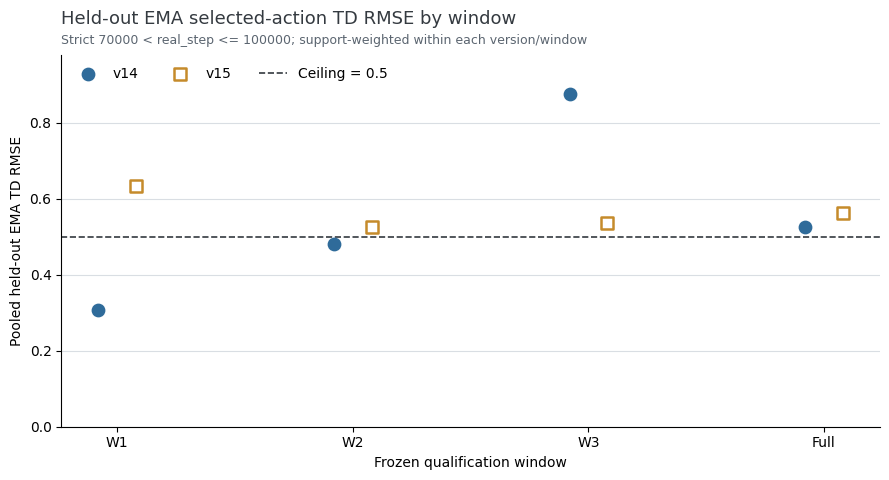

In [5]:
chart = calibration.loc[calibration.window.isin(['W1', 'W2', 'W3', 'Full'])].copy()
labels = ['W1', 'W2', 'W3', 'Full']
x = np.arange(len(labels), dtype=np.float64)
blue, gold, ink, grid = '#2F6B9A', '#C58B2B', '#343A40', '#D9DEE3'
fig, ax = plt.subplots(figsize=(9.0, 4.9), facecolor='white')
for version, offset, color, marker, face in [('v14', -0.08, blue, 'o', blue), ('v15', 0.08, gold, 's', 'white')]:
    values = chart.loc[chart.version == version].set_index('window').loc[labels, 'ema_rmse'].to_numpy()
    ax.scatter(x + offset, values, s=66, marker=marker, facecolor=face, edgecolor=color, linewidth=1.8, label=version, zorder=3)
ax.axhline(RMSE_CEILING, color=ink, linewidth=1.2, linestyle='--', label='Ceiling = 0.5')
ax.set_xticks(x, labels)
ax.set_ylim(0.0, 0.98)
ax.set_ylabel('Pooled held-out EMA TD RMSE')
ax.set_xlabel('Frozen qualification window')
ax.set_title('Held-out EMA selected-action TD RMSE by window', loc='left', color=ink, fontsize=13, pad=22)
ax.text(0.0, 1.02, 'Strict 70000 < real_step <= 100000; support-weighted within each version/window', transform=ax.transAxes, color='#5B6570', fontsize=9, va='bottom')
ax.grid(axis='y', color=grid, linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, ncol=3, loc='upper left')
fig.tight_layout()
plt.show()


### 4. Reconstruct train versus held-out online/EMA moments

All-valid moments include train plus held-out decisions. Subtracting held-out sums yields train-only bias, MAE, and SSE without assuming equal row support.


In [6]:
def reconstruct_split_moments(version, frame, source_label, prefix):
    train_n = require_counts(frame['actor/voc_continue_support'], 'train continue') + require_counts(frame['actor/voc_stop_support'], 'train stop')
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT)
    all_n = train_n + holdout_n
    all_bias = frame[f'{prefix}_td_bias'].to_numpy(dtype=np.float64)
    all_mae = frame[f'{prefix}_td_mae'].to_numpy(dtype=np.float64)
    all_rmse = frame[f'{prefix}_td_rmse'].to_numpy(dtype=np.float64)
    holdout_bias = frame[f'{prefix}_holdout_td_bias'].to_numpy(dtype=np.float64)
    holdout_mae = frame[f'{prefix}_holdout_td_mae'].to_numpy(dtype=np.float64)
    holdout_rmse = frame[f'{prefix}_holdout_td_rmse'].to_numpy(dtype=np.float64)
    train_sum = np.sum(all_n * all_bias - holdout_n * holdout_bias)
    train_abs = np.sum(all_n * all_mae - holdout_n * holdout_mae)
    train_sse = np.sum(all_n * np.square(all_rmse) - holdout_n * np.square(holdout_rmse))
    assert train_abs >= 0 and train_sse >= 0
    return [
        {'version': version, 'q_source': source_label, 'split': 'train', 'support': int(train_n.sum()), 'bias': train_sum / train_n.sum(), 'mae': train_abs / train_n.sum(), 'rmse': np.sqrt(train_sse / train_n.sum())},
        {'version': version, 'q_source': source_label, 'split': 'holdout', 'support': int(holdout_n.sum()), 'bias': np.dot(holdout_n, holdout_bias) / holdout_n.sum(), 'mae': np.dot(holdout_n, holdout_mae) / holdout_n.sum(), 'rmse': np.sqrt(np.dot(holdout_n, np.square(holdout_rmse)) / holdout_n.sum())},
    ]

split_rows = []
for version, frame in canonical.items():
    split_rows.extend(reconstruct_split_moments(version, frame, 'EMA', 'actor/voc_gate'))
    split_rows.extend(reconstruct_split_moments(version, frame, 'Online', 'actor/voc'))
split_moments = pd.DataFrame(split_rows)
expected_split_rmse = {
    ('v14', 'EMA', 'train'): 0.5865118456123475, ('v14', 'EMA', 'holdout'): 0.5247954789453232,
    ('v14', 'Online', 'train'): 0.5867927997052582, ('v14', 'Online', 'holdout'): 0.5248123566562356,
    ('v15', 'EMA', 'train'): 0.48913625344503686, ('v15', 'EMA', 'holdout'): 0.5637126651551874,
    ('v15', 'Online', 'train'): 0.48946925650925704, ('v15', 'Online', 'holdout'): 0.5646944857965209,
}
for row in split_moments.itertuples(index=False):
    assert np.isclose(row.rmse, expected_split_rmse[(row.version, row.q_source, row.split)], rtol=0.0, atol=1e-15)
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(split_moments)


,version,q_source,split,support,bias,mae,rmse
0,v14,EMA,train,54013,0.0001757239,0.2257031850,0.5865118456
1,v14,EMA,holdout,7703,-0.0173424071,0.2182068335,0.5247954789
2,v14,Online,train,54013,0.0004707586,0.2268510069,0.5867927997
3,v14,Online,holdout,7703,-0.0168082496,0.2190239446,0.5248123567
4,v15,EMA,train,57906,-0.0034510450,0.1969348060,0.4891362534
5,v15,EMA,holdout,8154,0.0058673889,0.2649639505,0.5637126652
6,v15,Online,train,57906,-0.0030080349,0.1991153192,0.4894692565
7,v15,Online,holdout,8154,0.0061157450,0.2675517220,0.5646944858


### 5. Tail observability, SSE concentration, and row-bias variance

V14 tail energy is recoverable because its logged loss is Huber and train MSE is reconstructible. V15 does not log the counterfactual Huber statistic, so its analogous tail energy cannot be recovered from aggregate rows; inventing it from half-MSE would be invalid.


In [7]:
error_structure_rows, concentration_rows, tail_rows = [], [], []
for version, frame in canonical.items():
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT).astype(np.float64)
    row_bias = frame['actor/voc_gate_holdout_td_bias'].to_numpy(dtype=np.float64)
    row_rmse = frame['actor/voc_gate_holdout_td_rmse'].to_numpy(dtype=np.float64)
    total_n = holdout_n.sum()
    pooled_bias = np.dot(holdout_n, row_bias) / total_n
    total_mse = np.dot(holdout_n, np.square(row_rmse)) / total_n
    within_row_variance = np.dot(holdout_n, np.square(row_rmse) - np.square(row_bias)) / total_n
    between_row_bias_variance = np.dot(holdout_n, np.square(row_bias - pooled_bias)) / total_n
    pooled_bias_squared = pooled_bias**2
    assert np.isclose(total_mse, within_row_variance + between_row_bias_variance + pooled_bias_squared, rtol=0.0, atol=1e-14)
    error_structure_rows.append({
        'version': version, 'ema_mse': total_mse, 'pooled_bias': pooled_bias,
        'within_row_variance': within_row_variance, 'between_row_bias_variance': between_row_bias_variance,
        'pooled_bias_squared': pooled_bias_squared, 'between_row_share_of_mse': between_row_bias_variance / total_mse,
    })
    row_sse = pd.Series(holdout_n * np.square(row_rmse)).sort_values(ascending=False)
    for top_k in (1, 5, 10):
        concentration_rows.append({'version': version, 'top_rows': top_k, 'sse': float(row_sse.head(top_k).sum()), 'share_of_total_sse': float(row_sse.head(top_k).sum() / row_sse.sum())})
    train_n = require_counts(frame['actor/voc_continue_support'], 'train continue') + require_counts(frame['actor/voc_stop_support'], 'train stop')
    all_n = train_n + require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT)
    train_sse_rows = all_n * np.square(frame['actor/voc_td_rmse'].to_numpy(dtype=np.float64)) - holdout_n * np.square(frame['actor/voc_holdout_td_rmse'].to_numpy(dtype=np.float64))
    train_half_mse = float(train_sse_rows.sum() / (2.0 * train_n.sum()))
    logged_loss = float(np.dot(train_n, frame['actor/voc_q_loss'].to_numpy(dtype=np.float64)) / train_n.sum())
    if version == 'v14':
        tail_identity = 2.0 * (train_half_mse - logged_loss)
        tail_fraction = tail_identity / (2.0 * train_half_mse)
    else:
        tail_identity = np.nan
        tail_fraction = np.nan
    tail_rows.append({
        'version': version, 'logged_loss_definition': 'Huber beta=1' if version == 'v14' else 'half-MSE',
        'logged_loss': logged_loss, 'reconstructed_train_half_mse': train_half_mse,
        'mse_minus_2huber': tail_identity, 'tail_energy_fraction': tail_fraction,
        'logged_minus_reconstructed_half_mse': logged_loss - train_half_mse,
    })

error_structure = pd.DataFrame(error_structure_rows)
concentration = pd.DataFrame(concentration_rows)
tail_observability = pd.DataFrame(tail_rows)
assert np.isclose(tail_observability.query("version == 'v14'").mse_minus_2huber.iloc[0], 0.09589030607307178, rtol=0.0, atol=1e-15)
assert np.isclose(tail_observability.query("version == 'v14'").tail_energy_fraction.iloc[0], 0.2784871447842638, rtol=0.0, atol=1e-15)
assert abs(tail_observability.query("version == 'v15'").logged_minus_reconstructed_half_mse.iloc[0]) < 2e-9
expected_top10 = {'v14': 0.7999049615724924, 'v15': 0.6939299981526046}
for version, expected in expected_top10.items():
    actual = concentration.query("version == @version and top_rows == 10").share_of_total_sse.iloc[0]
    assert np.isclose(actual, expected, rtol=0.0, atol=1e-15)
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(tail_observability)
    display(concentration)
    display(error_structure)


,version,logged_loss_definition,logged_loss,reconstructed_train_half_mse,mse_minus_2huber,tail_energy_fraction,logged_minus_reconstructed_half_mse
0,v14,Huber beta=1,0.1242177419,0.1721628949,0.0958903061,0.2784871448,-0.0479451530
1,v15,half-MSE,0.1197900774,0.1197900765,NaN,NaN,0.0000000009


,version,top_rows,sse,share_of_total_sse
0,v14,1,311.1193808693,0.1466516650
1,v14,5,1157.0343518924,0.5453887626
2,v14,10,1696.9867775455,0.7999049616
3,v15,1,342.7880044517,0.1322937490
4,v15,5,1287.2144514304,0.4967805855
5,v15,10,1798.0507853628,0.6939299982


,version,ema_mse,pooled_bias,within_row_variance,between_row_bias_variance,pooled_bias_squared,between_row_share_of_mse
0,v14,0.2754102947,-0.0173424071,0.1785494537,0.0965600819,0.0003007591,0.3506044755
1,v15,0.3177719689,0.0058673889,0.1892163488,0.1285211938,0.0000344263,0.4044447163


### 6. Q-loss, raw gradient norm, and update-density regimes

Rows are summarized within the preregistered windows rather than paired across runs. Q-norm quantiles are unweighted across successful update rows; support per update supplies the corresponding batch-density context.


In [8]:
regime_rows = []
for version, frame in canonical.items():
    frame = frame.copy()
    frame['train_count'] = require_counts(frame['actor/voc_continue_support'], 'train continue') + require_counts(frame['actor/voc_stop_support'], 'train stop')
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT)
    all_n = frame['train_count'].to_numpy(dtype=np.int64) + holdout_n
    frame['train_half_mse'] = (
        all_n * np.square(frame['actor/voc_td_rmse'].to_numpy(dtype=np.float64))
        - holdout_n * np.square(frame['actor/voc_holdout_td_rmse'].to_numpy(dtype=np.float64))
    ) / (2.0 * frame['train_count'])
    assert (frame['actor/voc_optimizer_stepped'] == 1).all()
    assert (frame['actor/voc_gate_optimizer_stepped'] == 0).all()
    assert (frame['actor/voc_gate_projection_post_error_norm'] == 0).all()
    assert (frame['actor/voc_update_count'] == frame['actor/voc_ema_gate_update_count']).all()
    assert (frame['actor/voc_update_count'] == frame['actor/voc_gate_update_count']).all()
    assert np.all(np.diff(frame['actor/voc_update_count']) == 1)
    for label, lower, upper in (*WINDOWS, ('Full', LOWER_STEP, UPPER_STEP)):
        window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
        train_support = int(window.train_count.sum())
        updates = int(window['actor/voc_optimizer_stepped'].sum())
        logged_loss = float(np.dot(window.train_count, window['actor/voc_q_loss']) / train_support)
        half_mse = float(np.dot(window.train_count, window.train_half_mse) / train_support)
        regime_rows.append({
            'version': version, 'window': label, 'updates': updates,
            'updates_per_10k_real_steps': updates / ((upper - lower) / 10000.0),
            'train_support': train_support, 'train_support_per_update': train_support / updates,
            'logged_q_loss': logged_loss, 'reconstructed_train_half_mse': half_mse,
            'q_raw_norm_mean': float(window['actor/voc_total_norm'].mean()),
            'q_raw_norm_median': float(window['actor/voc_total_norm'].median()),
            'q_raw_norm_p95': float(window['actor/voc_total_norm'].quantile(0.95)),
            'q_raw_norm_max': float(window['actor/voc_total_norm'].max()),
            'heldout_ema_rmse': pooled_rmse(window, 'actor/voc_gate_holdout_td_rmse'),
        })
regimes = pd.DataFrame(regime_rows)
full_regimes = regimes.loc[regimes.window == 'Full'].copy()
assert int(full_regimes.set_index('version').loc['v14', 'updates']) == 63
assert int(full_regimes.set_index('version').loc['v15', 'updates']) == 58
assert np.isclose(full_regimes.set_index('version').loc['v14', 'reconstructed_train_half_mse'], 0.17216289489296763, rtol=0.0, atol=1e-15)
assert np.isclose(full_regimes.set_index('version').loc['v15', 'reconstructed_train_half_mse'], 0.11979007653386242, rtol=0.0, atol=1e-15)
with pd.option_context('display.float_format', lambda value: f'{value:.8f}'):
    display(regimes)


,version,window,updates,updates_per_10k_real_steps,train_support,train_support_per_update,logged_q_loss,reconstructed_train_half_mse,q_raw_norm_mean,q_raw_norm_median,q_raw_norm_p95,q_raw_norm_max,heldout_ema_rmse
0,v14,W1,32,32.00000000,26203,818.84375000,0.03023360,0.03207443,43.72973061,35.32936668,90.19791794,129.20948792,0.30704685
1,v14,W2,19,19.00000000,16949,892.05263158,0.07255180,0.09577078,106.73843173,110.85028839,209.84149017,289.92892456,0.48057633
2,v14,W3,12,12.00000000,10861,905.08333333,0.43158837,0.62934990,391.38563220,313.61814880,864.62223511,886.30688477,0.87534108
3,v14,Full,63,21.00000000,54013,857.34920635,0.12421774,0.17216289,128.95252649,62.38666916,443.18048401,886.30688477,0.52479548
4,v15,W1,19,19.00000000,17739,933.63157895,0.17094067,0.17094067,218.90797123,132.38024902,753.04686890,767.42517090,0.63500005
5,v15,W2,26,26.00000000,24741,951.57692308,0.10413037,0.10413037,185.88019914,119.65213394,483.49061584,802.54064941,0.52621979
6,v15,W3,13,13.00000000,15426,1186.61538462,0.08608571,0.08608570,119.53735674,138.90916443,191.88206787,220.84526062,0.53629642
7,v15,Full,58,19.33333333,57906,998.37931034,0.11979008,0.11979008,181.82969429,131.73944092,537.22787933,802.54064941,0.56371267


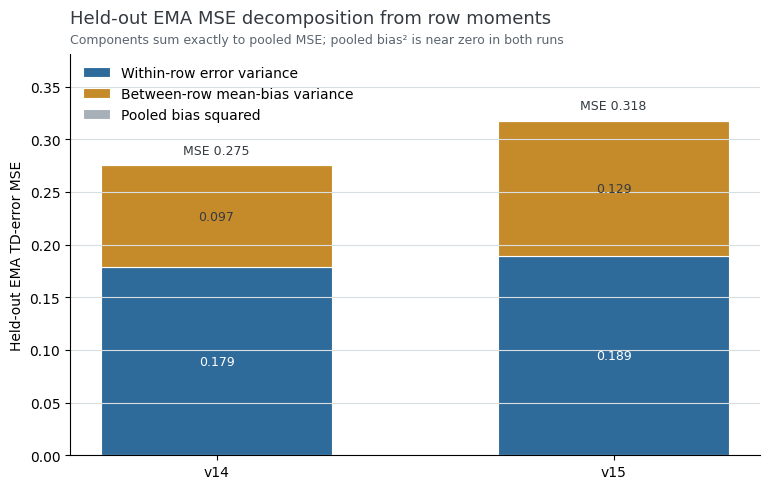

In [9]:
decomposition = error_structure.set_index('version').loc[['v14', 'v15']]
components = [
    ('within_row_variance', 'Within-row error variance', blue),
    ('between_row_bias_variance', 'Between-row mean-bias variance', gold),
    ('pooled_bias_squared', 'Pooled bias squared', '#A7AFB8'),
]
fig, ax = plt.subplots(figsize=(7.8, 5.0), facecolor='white')
bottom = np.zeros(2, dtype=np.float64)
positions = np.arange(2)
for column, label, color in components:
    values = decomposition[column].to_numpy(dtype=np.float64)
    ax.bar(positions, values, bottom=bottom, width=0.58, color=color, edgecolor='white', linewidth=0.8, label=label)
    if column != 'pooled_bias_squared':
        for position, value, base in zip(positions, values, bottom):
            ax.text(position, base + value / 2, f'{value:.3f}', ha='center', va='center', color='white' if column == 'within_row_variance' else ink, fontsize=9)
    bottom += values
for position, total in zip(positions, decomposition.ema_mse):
    ax.text(position, total + 0.008, f'MSE {total:.3f}', ha='center', va='bottom', color=ink, fontsize=9)
ax.set_xticks(positions, ['v14', 'v15'])
ax.set_ylim(0.0, max(decomposition.ema_mse) * 1.20)
ax.set_ylabel('Held-out EMA TD-error MSE')
ax.set_title('Held-out EMA MSE decomposition from row moments', loc='left', color=ink, fontsize=13, pad=22)
ax.text(0.0, 1.02, 'Components sum exactly to pooled MSE; pooled bias² is near zero in both runs', transform=ax.transAxes, color='#5B6570', fontsize=9, va='bottom')
ax.grid(axis='y', color=grid, linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
plt.show()


## Takeaways

1. **V15 does not pass the unchanged calibration gate.** Its held-out EMA RMSE is 0.5637127 on support 8,154, worse than v14's 0.5247955 on support 7,703. Both fail 0.5; v15's SSE excess is 552.6126.
2. **The temporal regime changes direction.** V15 substantially improves the v14 W3 spike (0.8753→0.5363) but reverses W1 from passing to 0.6350 and nudges W2 above the ceiling. This supports an error-redistribution description, not a causal mechanism verdict.
3. **Observed train and held-out calibration move in opposite directions.** Reconstructed online train RMSE improves 0.5868→0.4895 while held-out online RMSE worsens 0.5248→0.5647. Because the gate affects the on-policy trajectory and support, this is not a randomized train/holdout treatment comparison.
4. **A single global bias is not the issue visible here.** Pooled EMA bias is -0.0173 for v14 and +0.0059 for v15, yet MSE rises. V15 has higher within-row variance and higher between-row mean-bias variance; the latter is 40.44% of MSE versus 35.06% in v14.
5. **Tail claims are asymmetric by telemetry design.** V14's exact train `MSE - 2*Huber` is 0.0958903 (27.85% of squared-error energy). V15's logged half-MSE matches the reconstructed half-MSE, but its counterfactual Huber/tail energy is not recoverable from these aggregate CSV rows.
6. **Optimization exposure differs.** The canonical slice has 63 v14 versus 58 v15 Q updates (21.0 vs 19.33 per 10k real steps), while v15 carries more train support per update. Median raw Q gradient norm is higher in v15, but both runs have successful lockstep Q/EMA/projection updates, zero projected post-error, an unused gate optimizer, and zero CSV-observable skip/non-finite counters.
7. **Lineage recommendation is about attribution, not expected performance.** The immediate schema-9 path keeps v15 half-MSE and changes only the common-mode one-delta semantics. A v14-Huber-plus-common sibling is second priority: its frozen RMSE and observed gradient-risk indicators are lower, but relative to schema 8 it changes both loss and common-mode semantics, weakening one-change attribution. These observations do not predict that either path will pass.
8. **What remains unresolved:** individual-error tails, state/action-specific calibration, ModelNet safety, full schema/artifact integrity, and any causal effect of the loss change require evidence beyond these two actor CSVs.

Overall assessment: **ready to share as a reproducible descriptive comparison, with the stated source and causal caveats.**
